In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/WESAD_Project/Signals/signals verified'

print("WESAD Project:")
print(os.listdir('/content/drive/MyDrive/WESAD_Project'))

print("\nSignals:")
print(os.listdir('/content/drive/MyDrive/WESAD_Project/Signals'))

print("\nSubjects:")
print(os.listdir(base_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WESAD Project:
['rf_stress_model.pkl', 'Signals', 'ai-stress-detection-ffe3d-firebase-adminsdk-fbsvc-5196aad3cf.json']

Signals:
['signals verified']

Subjects:
['S3', 'S4', 'S2']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.listdir('/content/drive/MyDrive/WESAD_Project/Signals/signals verified')

import os
import pandas as pd

base_path = '/content/drive/MyDrive/WESAD_Project/Signals/signals verified'
subjects = ['S2', 'S3', 'S4']
os.listdir(os.path.join(base_path, 'S2'))

['S2_respiban.txt', 'S2.pkl', 'S2_E4_Data', 'S2_readme.txt', 'S2_quest.csv']

In [ ]:
import pickle

s2_pkl_path = '/content/drive/MyDrive/WESAD_Project/Signals/signals verified/S2/S2.pkl'

with open(s2_pkl_path, 'rb') as f:
    s2_data = pickle.load(f, encoding='latin1')

type(s2_data)

s2_data.keys()

dict_keys(['signal', 'label', 'subject'])

In [ ]:
s2_data['signal'].keys()
s2_data['signal']['chest'].keys()
set(s2_data['label'])


{np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(6),
 np.int32(7)}

In [ ]:
s2_data['signal']['chest'].keys()

# Correct extraction using proper keys
ecg = s2_data['signal']['chest']['ECG'].flatten()
eda = s2_data['signal']['chest']['EDA'].flatten()
temp = s2_data['signal']['chest']['Temp'].flatten()
labels = s2_data['label'].flatten()

len(ecg), len(eda), len(temp), len(labels)

import numpy as np

# Keep only baseline, stress, meditation
valid_idx = np.where(np.isin(labels, [0, 1, 3]))[0]

ecg = ecg[valid_idx]
eda = eda[valid_idx]
temp = temp[valid_idx]
labels = labels[valid_idx]

# Binary mapping
labels = np.where(labels == 1, 1, 0)

set(labels)


def extract_features(ecg, eda, temp, labels, window_size):
    features = []
    feature_labels = []

    for i in range(0, len(labels) - window_size, window_size):
        ecg_win = ecg[i:i+window_size]
        eda_win = eda[i:i+window_size]
        temp_win = temp[i:i+window_size]
        label_win = labels[i:i+window_size]

        # Majority label in window
        label = np.round(np.mean(label_win))

        # Feature set
        feat = [
            np.mean(ecg_win),
            np.std(ecg_win),
            np.mean(eda_win),
            np.std(eda_win),
            np.mean(temp_win),
            np.std(temp_win)
        ]

        features.append(feat)
        feature_labels.append(label)

    return np.array(features), np.array(feature_labels)

fs = 700   # sampling frequency (Hz)
window_size = 5 * fs   # 5-second window
X_s2, y_s2 = extract_features(ecg, eda, temp, labels, window_size)

X_s2.shape, y_s2.shape



((913, 6), (913,))

In [ ]:
import pickle
import numpy as np
import pandas as pd

def process_subject(subject_id, base_path, window_size):
    # Load PKL
    pkl_path = f"{base_path}/{subject_id}/{subject_id}.pkl"
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # Extract signals
    ecg = data['signal']['chest']['ECG'].flatten()
    eda = data['signal']['chest']['EDA'].flatten()
    temp = data['signal']['chest']['Temp'].flatten()
    labels = data['label'].flatten()

    # Clean labels
    valid_idx = np.where(np.isin(labels, [0, 1, 3]))[0]
    ecg = ecg[valid_idx]
    eda = eda[valid_idx]
    temp = temp[valid_idx]
    labels = labels[valid_idx]

    labels = np.where(labels == 1, 1, 0)

    # Feature extraction
    X, y = extract_features(ecg, eda, temp, labels, window_size)

    # Create DataFrame
    columns = [
        'ECG_mean', 'ECG_std',
        'EDA_mean', 'EDA_std',
        'Temp_mean', 'Temp_std'
    ]
    df = pd.DataFrame(X, columns=columns)
    df['Label'] = y
    df['Subject'] = subject_id

    return df


In [ ]:
import pickle
import numpy as np
import pandas as pd

def process_subject(subject_id, base_path, window_size):
    # Load PKL
    pkl_path = f"{base_path}/{subject_id}/{subject_id}.pkl"
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # Extract signals
    ecg = data['signal']['chest']['ECG'].flatten()
    eda = data['signal']['chest']['EDA'].flatten()
    temp = data['signal']['chest']['Temp'].flatten()
    labels = data['label'].flatten()

    # Clean labels
    valid_idx = np.where(np.isin(labels, [0, 1, 3]))[0]
    ecg = ecg[valid_idx]
    eda = eda[valid_idx]
    temp = temp[valid_idx]
    labels = labels[valid_idx]

    labels = np.where(labels == 1, 1, 0)

    # Feature extraction
    X, y = extract_features(ecg, eda, temp, labels, window_size)

    # Create DataFrame
    columns = [
        'ECG_mean', 'ECG_std',
        'EDA_mean', 'EDA_std',
        'Temp_mean', 'Temp_std'
    ]
    df = pd.DataFrame(X, columns=columns)
    df['Label'] = y
    df['Subject'] = subject_id

    return df


In [ ]:
base_path = '/content/drive/MyDrive/WESAD_Project/Signals/signals verified'

df_s3 = process_subject('S3', base_path, window_size)
df_s4 = process_subject('S4', base_path, window_size)

df_s3.shape, df_s4.shape


((973, 8), (967, 8))

In [ ]:
df_s2 = process_subject('S2', base_path, window_size)
df_s2.shape

final_df = pd.concat([df_s2, df_s3, df_s4], ignore_index=True)
final_df.shape


(2853, 8)

In [ ]:
from sklearn.model_selection import train_test_split

# Features and labels
X = final_df.drop(['Label', 'Subject'], axis=1)
y = final_df['Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((2282, 6), (571, 6))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.9807355516637478

In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       433
         1.0       0.98      0.94      0.96       138

    accuracy                           0.98       571
   macro avg       0.98      0.97      0.97       571
weighted avg       0.98      0.98      0.98       571

[[430   3]
 [  8 130]]


In [ ]:
import joblib

model_path = '/content/drive/MyDrive/WESAD_Project/rf_stress_model.pkl'
joblib.dump(rf_model, model_path)

model_path


'/content/drive/MyDrive/WESAD_Project/rf_stress_model.pkl'

In [ ]:
!pip install firebase-admin flask


In [1]:
import firebase_admin
from firebase_admin import credentials, db
import os

FIREBASE_KEY_PATH = os.environ.get("FIREBASE_KEY_PATH")

if FIREBASE_KEY_PATH and not firebase_admin._apps:
    cred = credentials.Certificate(FIREBASE_KEY_PATH)

    firebase_admin.initialize_app(cred, {
        'databaseURL': 'YOUR_FIREBASE_DATABASE_URL'
    })

    print("Firebase initialized successfully")
else:
    print("Firebase credentials not configured.")

Firebase credentials not configured.


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))
print(os.listdir('/content/drive/MyDrive/WESAD_Project'))
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if file.endswith('.json'):
            print(os.path.join(root, file))

['hall ticket 4.pdf', 'Screenshot_2023-12-27-21-47-18-18.jpg', 'Document from Baskar Bkr.pdf', 'Generated PDF from Image Files.pdf', 'Contacts-2025-08-04.vcf', 'BASKAR_E RESUME_MOCK.pdf', 'Colab Notebooks', 'APPRENTICES OFFER LETTER 656.pdf', 'BASKAR_E_RESUME.pdf', 'WESAD_Project']
['rf_stress_model.pkl', 'Signals', 'ai-stress-detection-ffe3d-firebase-adminsdk-fbsvc-5196aad3cf.json']
/content/drive/MyDrive/WESAD_Project/ai-stress-detection-ffe3d-firebase-adminsdk-fbsvc-5196aad3cf.json


In [ ]:
import joblib

model = joblib.load(
    '/content/drive/MyDrive/WESAD_Project/rf_stress_model.pkl'
)

print("ML model loaded successfully")

import numpy as np

def build_feature_vector(ecg, eda, temp):
    return np.array([[
        np.mean(ecg), np.std(ecg),
        np.mean(eda), np.std(eda),
        np.mean(temp), np.std(temp)
    ]])


ML model loaded successfully


In [ ]:
from flask import Flask, jsonify

app = Flask(__name__)

@app.route('/predict', methods=['GET'])
def predict_stress():
    ref = db.reference('sensor_data')
    data = ref.get()

    if data is None:
        return jsonify({'error': 'No sensor data available'})

    # Read values (ESP32 will send arrays or rolling buffers later)
    ecg = data.get('ecg', [])
    eda = data.get('eda', [])
    temp = data.get('temp', [])

    if not ecg or not eda or not temp:
        return jsonify({'error': 'Incomplete sensor data'})

    # Build feature vector
    X = build_feature_vector(ecg, eda, temp)

    # Predict
    prediction = model.predict(X)[0]

    result = 'Stress' if prediction == 1 else 'No Stress'

    return jsonify({
        'stress_level': result,
        'prediction': int(prediction)
    })

print("Flask API ready")


Flask API ready


In [ ]:
app.run(host='0.0.0.0', port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_TOKEN")



In [ ]:
public_url = ngrok.connect(5000)
public_url


<NgrokTunnel: "https://navally-monotonous-garret.ngrok-free.dev" -> "http://localhost:5000">

In [ ]:
!pip install firebase-admin
!pip install scikit-learn
!pip install pandas

^C


In [ ]:
import firebase_admin
from firebase_admin import credentials, db

# FIX: check if already initialized
if not firebase_admin._apps:
    cred = credentials.Certificate("serviceAccountKey.json")
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'YOUR_FIREBASE_DATABASE_URL'
    })

print("Firebase Connected ✅")

Firebase Connected ✅


In [ ]:
data = db.reference().get()
print(data)

None


In [ ]:
ref = db.reference('sensor')

ref.set({
    'ecg': 3000,
    'gsr': 50,
    'temp': 33
})

print("Test sensor data uploaded")

Test sensor data uploaded


In [ ]:
ref = db.reference('sensor')
data = ref.get()

ecg = data['ecg']
gsr = data['gsr']
temp = data['temp']

print(ecg, gsr, temp)

3000 50 33


In [ ]:
!pip install pandas scikit-learn joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/WESAD/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = "/content/drive/MyDrive/WESAD_Project/Signals/signals verified/"



In [ ]:
import pickle

file_path = "/content/drive/MyDrive/WESAD_Project/Signals/signals verified/S2/S2.pkl"

with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Loaded successfully ✅")

Loaded successfully ✅


In [ ]:
ecg = data['signal']['chest']['ECG']
eda = data['signal']['chest']['EDA']
temp = data['signal']['chest']['Temp']
labels = data['label']

print(len(ecg), len(eda), len(temp), len(labels))

4255300 4255300 4255300 4255300


In [ ]:
import numpy as np

window_size = 700   # can adjust later

X = []
y = []

for i in range(0, len(labels) - window_size, window_size):

    ecg_feat = np.mean(ecg[i:i+window_size])
    gsr_feat = np.mean(eda[i:i+window_size])
    temp_feat = np.mean(temp[i:i+window_size])

    label = labels[i]

    # keep valid stress labels
    if label in [1, 2, 3]:
        X.append([ecg_feat, gsr_feat, temp_feat])
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (2121, 3)
Labels shape: (2121,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       229
           2       1.00      1.00      1.00       123
           3       1.00      1.00      1.00        73

    accuracy                           1.00       425
   macro avg       1.00      1.00      1.00       425
weighted avg       1.00      1.00      1.00       425



In [ ]:
import joblib
joblib.dump(model, "stress_model.pkl")
import os
print(os.listdir())
model = joblib.load("stress_model.pkl")
import numpy as np

test = np.array([[3000, 50, 33]])  # sample firebase-like values
print(model.predict(test))

['.config', 'stress_model.pkl', 'drive', 'sample_data']
[2]


ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)


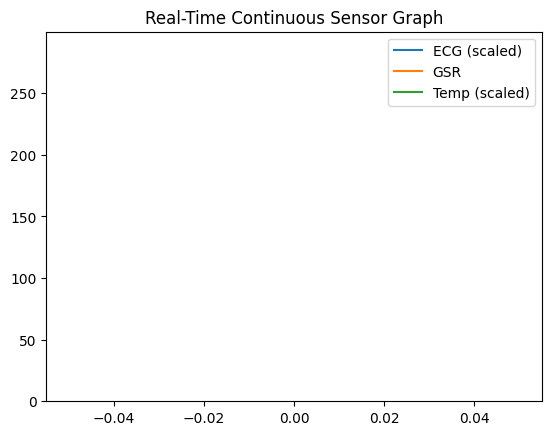

ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESSED (57.33%)
ECG:3000 GSR:50 Temp:33 → STRESS

In [ ]:
import firebase_admin
from firebase_admin import credentials, db
import joblib
import numpy as np
import time
import matplotlib.pyplot as plt

# 🔹 Firebase setup
if not firebase_admin._apps:
    cred = credentials.Certificate("serviceAccountKey.json")
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'YOUR_FIREBASE_DATABASE_URL'
    })

# 🔹 Load model
model = joblib.load("stress_model.pkl")

ref = db.reference('sensor')

# 🔹 Data storage
ecg_list = []
gsr_list = []
temp_list = []

plt.ion()
fig, ax = plt.subplots()

while True:
    data = ref.get()

    if data is None:
        time.sleep(2)
        continue

    # 🔹 Read values
    ecg = data.get('ecg', 0)
    gsr = data.get('gsr', 0)
    temp = data.get('temp', 0)

    # 🔥 NORMALIZATION (IMPORTANT)
    ecg_plot = ecg / 10       # scale down ECG
    gsr_plot = gsr            # keep as is
    temp_plot = temp * 10     # scale up temp

    # 🔹 Store values
    ecg_list.append(ecg_plot)
    gsr_list.append(gsr_plot)
    temp_list.append(temp_plot)

    # keep last 50 values
    ecg_list = ecg_list[-50:]
    gsr_list = gsr_list[-50:]
    temp_list = temp_list[-50:]

    # 🔹 Prediction
    input_data = np.array([[ecg, gsr, temp]])
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0]
    confidence = round(max(prob) * 100, 2)

    label_map = {1: "RELAXED", 2: "STRESSED", 3: "NORMAL"}
    stress_label = label_map.get(prediction, "UNKNOWN")

    print(f"ECG:{ecg} GSR:{gsr} Temp:{temp} → {stress_label} ({confidence}%)")

    # 🔹 Update Firebase
    ref.update({
        "stress": stress_label,
        "confidence": confidence
    })

    # 🔹 GRAPH UPDATE
    ax.clear()

    ax.plot(ecg_list, label="ECG (scaled)")
    ax.plot(gsr_list, label="GSR")
    ax.plot(temp_list, label="Temp (scaled)")

    # 🔥 CLEAN Y-AXIS (NO CLUTTER)
    ax.set_ylim(0, 300)
    ax.set_yticks(range(0, 300, 50))

    ax.set_title("Real-Time Continuous Sensor Graph")
    ax.legend()

    plt.pause(0.01)

    time.sleep(2)